In [ ]:
# ==============================================================================
# 1. CONEXIÓN A GOOGLE DRIVE Y CARGA DE DATOS
# ==============================================================================
from google.colab import drive
import pandas as pd
import numpy as np

# Montar Google Drive
drive.mount('/content/drive')

# Ruta directa al dataset en la carpeta especificada
file_path = '/content/drive/MyDrive/proyecto dataset/social_media_clean.csv'

# Cargar dataset
df = pd.read_csv(file_path)

print("✅ Dataset cargado correctamente.")
print(f"Dimensiones del dataset: {df.shape[0]} filas, {df.shape[1]} columnas")

Mounted at /content/drive
✅ Dataset cargado correctamente.
Dimensiones del dataset: 1491 filas, 30 columnas


In [ ]:
# ==============================================================================
# 2. AUDITORÍA DE DATOS Y CONFIGURACIÓN DE ESTILOS
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del tema gráfico
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10

print("--- AUDITORÍA DE VALORES NULOS Y TIPOS DE DATOS ---")
audit_df = pd.DataFrame({
    'Tipo_Dato': df.dtypes,
    'Valores_Nulos': df.isnull().sum(),
    'Porcentaje_Nulos (%)': (df.isnull().sum() / len(df)) * 100,
    'Valores_Unicos': df.nunique()
})
display(audit_df)

print("\n--- RESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS ---")
display(df.describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']])

--- AUDITORÍA DE VALORES NULOS Y TIPOS DE DATOS ---


,Tipo_Dato,Valores_Nulos,Porcentaje_Nulos (%),Valores_Unicos
User_ID,object,0,0.0,1491
Age,int64,0,0.0,30
Gender,object,0,0.0,4
Occupation,object,0,0.0,5
Relationship_Status,object,0,0.0,4
Primary_Platform,object,0,0.0,7
Daily_Usage_Hours,float64,0,0.0,94
Platforms_Used_Count,int64,0,0.0,8
Posts_Per_Week,int64,0,0.0,13
Late_Night_Usage,object,0,0.0,3



--- RESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS ---


,count,mean,std,min,25%,50%,75%,max
Age,1491.0,29.380282,8.560538,15.0,22.00,29.0,37.0,44.0
Daily_Usage_Hours,1491.0,4.313548,2.188261,0.0,2.80,4.3,5.8,10.1
Platforms_Used_Count,1491.0,3.231388,1.683551,1.0,2.00,3.0,4.0,8.0
Posts_Per_Week,1491.0,3.934943,1.945687,0.0,3.00,4.0,5.0,12.0
Notifications_Per_Day,1491.0,60.274983,33.184104,5.0,36.00,59.0,81.5,165.0
FOMO_Score,1491.0,5.248826,2.374604,0.0,3.80,5.4,6.9,10.0
Social_Comparison_Score,1491.0,5.304292,2.244569,0.0,3.90,5.4,6.8,10.0
Validation_Seeking_Score,1491.0,4.818444,2.287809,0.0,3.40,4.9,6.4,10.0
Scroll_Without_Purpose,1491.0,5.456338,2.081153,0.0,4.00,5.5,6.9,10.0
Anxiety_Score,1491.0,4.944668,2.305984,0.0,3.45,5.0,6.6,10.0


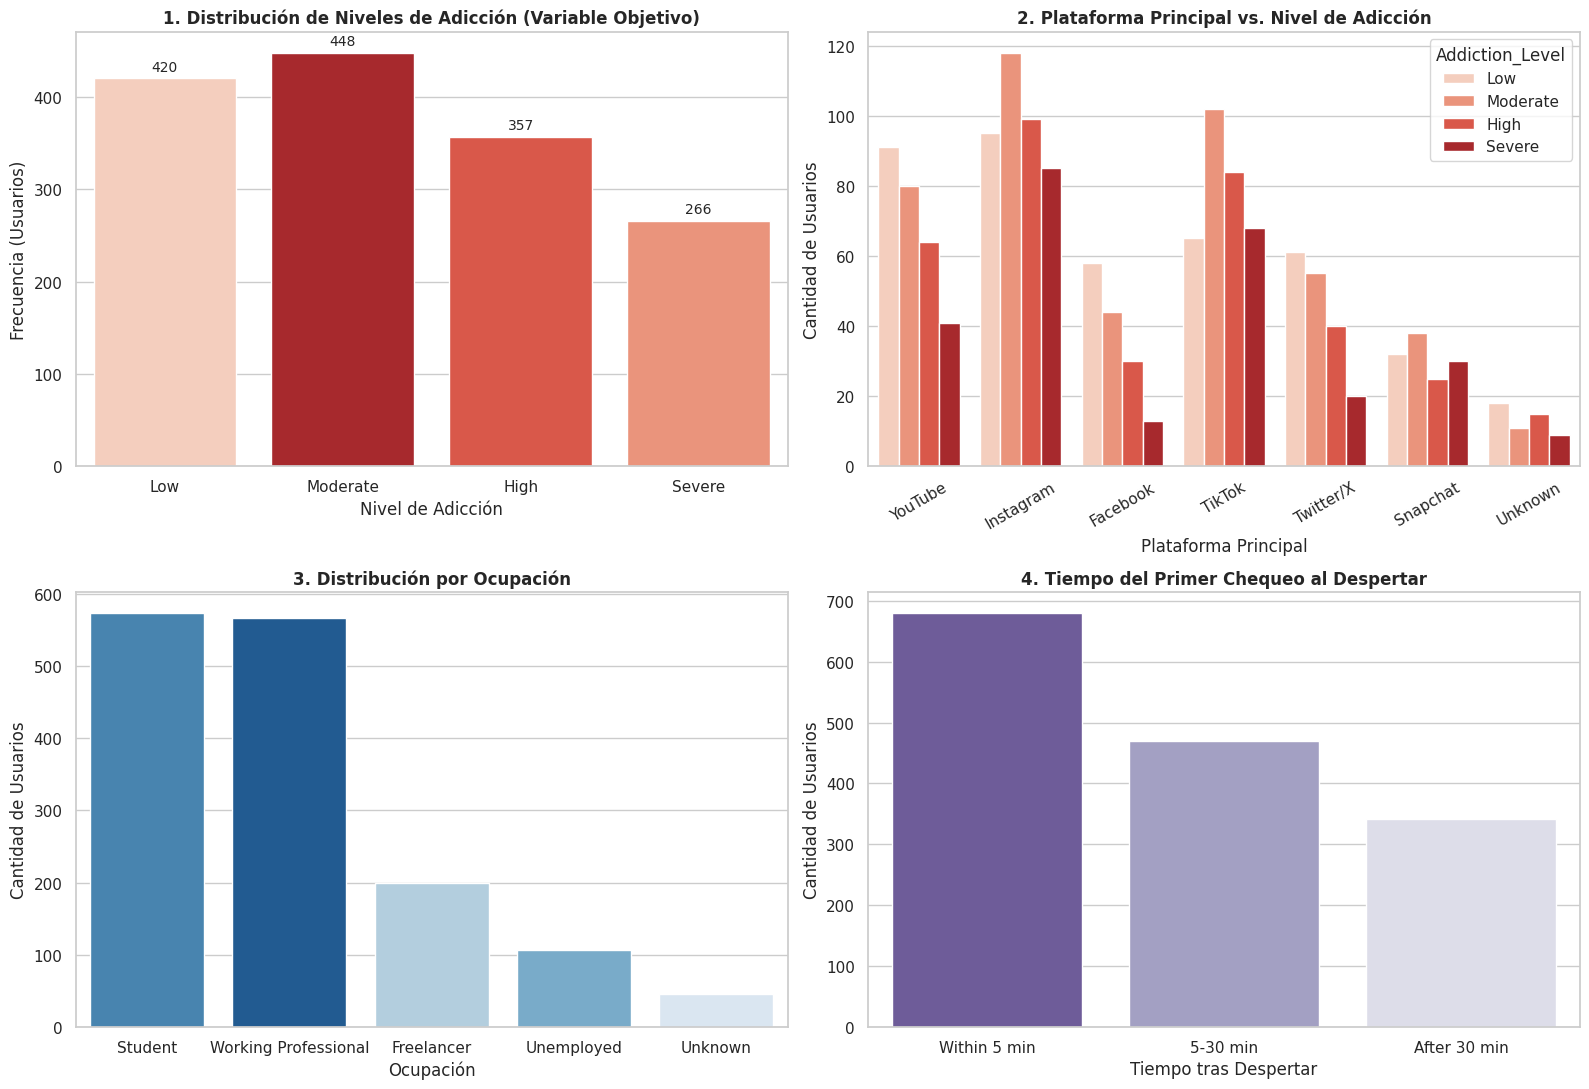

In [ ]:
# ==============================================================================
# 3. ANÁLISIS DE LA VARIABLE OBJETIVO Y VARIABLES CATEGÓRICAS
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1. Variable Objetivo: Addiction_Level
order_addiction = ['Low', 'Moderate', 'High', 'Severe']
sns.countplot(
    data=df,
    x='Addiction_Level',
    hue='Addiction_Level',
    order=order_addiction,
    ax=axes[0, 0],
    palette='Reds',
    legend=False
)
axes[0, 0].set_title('1. Distribución de Niveles de Adicción (Variable Objetivo)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Nivel de Adicción')
axes[0, 0].set_ylabel('Frecuencia (Usuarios)')
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')

# 2. Plataforma Principal vs Nivel de Adicción
sns.countplot(
    data=df,
    x='Primary_Platform',
    hue='Addiction_Level',
    hue_order=order_addiction,
    ax=axes[0, 1],
    palette='Reds'
)
axes[0, 1].set_title('2. Plataforma Principal vs. Nivel de Adicción', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Plataforma Principal')
axes[0, 1].set_ylabel('Cantidad de Usuarios')
axes[0, 1].tick_params(axis='x', rotation=30)

# 3. Ocupación de los Usuarios
sns.countplot(
    data=df,
    x='Occupation',
    hue='Occupation',
    order=df['Occupation'].value_counts().index,
    ax=axes[1, 0],
    palette='Blues_r',
    legend=False
)
axes[1, 0].set_title('3. Distribución por Ocupación', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Ocupación')
axes[1, 0].set_ylabel('Cantidad de Usuarios')

# 4. Primer Chequeo en la Mañana (Hábitos Iniciales)
sns.countplot(
    data=df,
    x='First_Check_Morning',
    hue='First_Check_Morning',
    order=['Within 5 min', '5-30 min', 'After 30 min'],
    ax=axes[1, 1],
    palette='Purples_r',
    legend=False
)
axes[1, 1].set_title('4. Tiempo del Primer Chequeo al Despertar', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Tiempo tras Despertar')
axes[1, 1].set_ylabel('Cantidad de Usuarios')

plt.tight_layout()
plt.show()

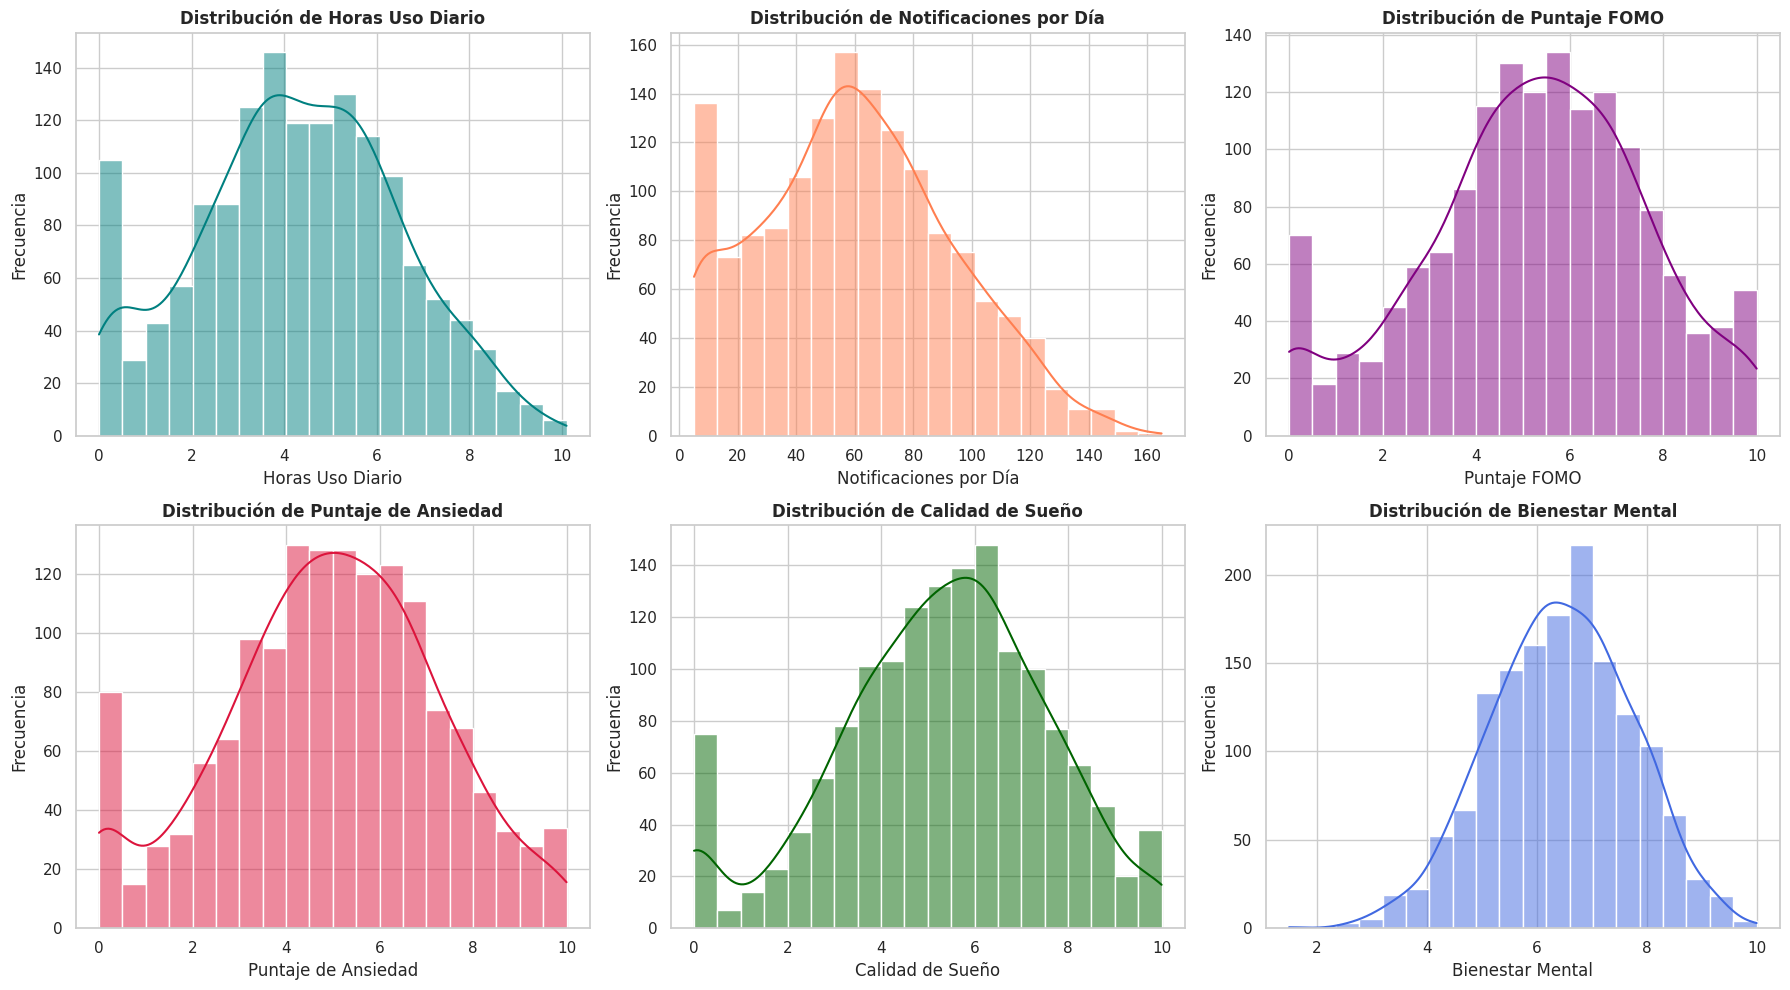

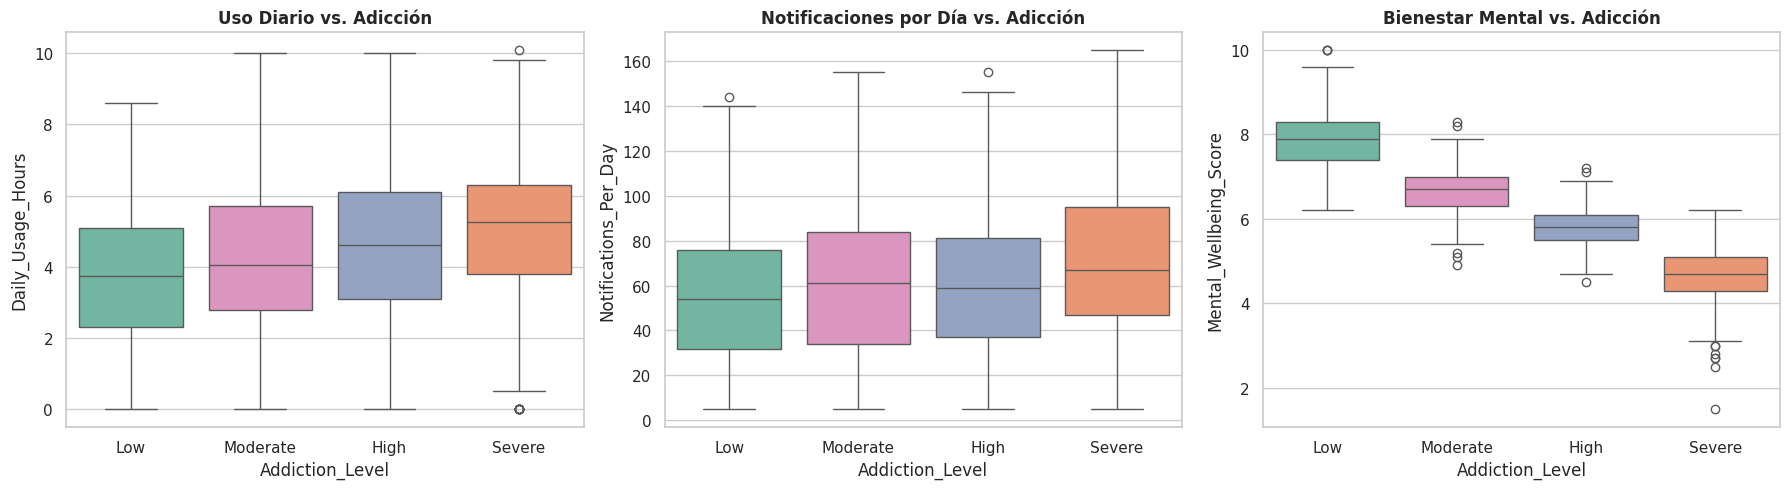

In [ ]:
# ==============================================================================
# 4. DISTRIBUCIÓN DE VARIABLES NUMÉRICAS Y DETECCIÓN DE OUTLIERS (CORREGIDO)
# ==============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

features_to_plot = [
    ('Daily_Usage_Hours', 'Horas Uso Diario', 'teal'),
    ('Notifications_Per_Day', 'Notificaciones por Día', 'coral'),
    ('FOMO_Score', 'Puntaje FOMO', 'purple'),
    ('Anxiety_Score', 'Puntaje de Ansiedad', 'crimson'),
    ('Sleep_Quality_Score', 'Calidad de Sueño', 'darkgreen'),
    ('Mental_Wellbeing_Score', 'Bienestar Mental', 'royalblue')
]

for ax, (col, name, color) in zip(axes.flatten(), features_to_plot):
    sns.histplot(df[col], kde=True, ax=ax, color=color, bins=20)
    ax.set_title(f'Distribución de {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel(name)
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Diagrama de Cajas (Boxplots) para detectar Outliers respecto a la adicción
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(
    data=df,
    x='Addiction_Level',
    y='Daily_Usage_Hours',
    hue='Addiction_Level',
    order=order_addiction,
    ax=axes[0],
    palette='Set2',
    legend=False
)
axes[0].set_title('Uso Diario vs. Adicción', fontweight='bold')

sns.boxplot(
    data=df,
    x='Addiction_Level',
    y='Notifications_Per_Day',
    hue='Addiction_Level',
    order=order_addiction,
    ax=axes[1],
    palette='Set2',
    legend=False
)
axes[1].set_title('Notificaciones por Día vs. Adicción', fontweight='bold')

sns.boxplot(
    data=df,
    x='Addiction_Level',
    y='Mental_Wellbeing_Score',
    hue='Addiction_Level',
    order=order_addiction,
    ax=axes[2],
    palette='Set2',
    legend=False
)
axes[2].set_title('Bienestar Mental vs. Adicción', fontweight='bold')

plt.tight_layout()
plt.show()